
# Thesis-Ready Multimodal Sentiment Analysis
## Uncertainty-Aware Co-Attention + Evidential Deep Learning (EDL)

Dataset:
- `D:/MVSA_SINGLE`


In [1]:

# ============================================================
# CONFIGURATION
# ============================================================

class CFG:

    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"


    # =========================
    # EARLY STOPPING
    # =========================
    PATIENCE = 8

    # =========================
    # SPLIT
    # =========================
    TEST_SIZE = 0.15
    VAL_SIZE = 0.15

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda"


In [2]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=',')
df.columns = ["id", "text_label", "image_label", "final_label"]

def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

df = df[df.apply(is_valid, axis=1)]
df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

# Track failed samples for debugging
failed_samples = []

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

if empty_text_count > 0:
    print("IDs with empty text:")
    empty_ids = df[df["text"] == ""]["id"].tolist()
    for idx in empty_ids[:10]:  # Show first 10
        print(f"  - {idx}")
    if len(empty_ids) > 10:
        print(f"  ... and {len(empty_ids) - 10} more")
    print()

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()


Dataset size after filtering: 4511

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [3]:
# ============================================================
# CELL 3: IMPORTS & SEED
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import warnings, random, os, copy

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device(CFG.DEVICE if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [4]:
# ============================================================
# CELL 4: DATASET & DATALOADER
# ============================================================

# --- Hyperparameters ---
class HP:
    PROJ_DIM = 128           # Reduced: 256→128 to limit capacity on small dataset
    BACKBONE_LR = 5e-6       # Reduced: 2e-5→5e-6 to prevent backbone overfitting
    HEAD_LR = 5e-4           # Reduced: 1e-3→5e-4 for smoother convergence
    WEIGHT_DECAY = 0.02      # Increased: 0.01→0.02 for stronger L2 regularization
    BATCH_SIZE = 32
    MAX_EPOCHS = 50
    KL_ANNEALING_EPOCHS = 5  # Faster: 10→5 so KL regularizer kicks in earlier
    FOCAL_GAMMA = 2.0        # Increased: 1.0→2.0 to ignore easy samples harder
    CLASS_WEIGHT_BETA = 0.99
    DROPOUT = 0.5            # Increased: 0.3→0.5 for stronger regularization
    GRAD_CLIP_NORM = 1.0
    EARLY_STOP_PATIENCE = 10
    BACKBONE_FREEZE_EPOCHS = 8  # Extended: 3→8 to prevent early memorization
    MAX_TEXT_LEN = 128
    NUM_CLASSES = 3
    IMG_SIZE = 224

# --- Train/Val/Test Split ---
train_df, test_df = train_test_split(
    df, test_size=CFG.TEST_SIZE, random_state=42, stratify=df["label"]
)
train_df, val_df = train_test_split(
    train_df, test_size=CFG.VAL_SIZE / (1 - CFG.TEST_SIZE),
    random_state=42, stratify=train_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"Train label distribution:\n{train_df['label'].value_counts().sort_index()}")

# --- Compute Effective Number Class Weights ---
class_counts = train_df["label"].value_counts().sort_index().values.astype(float)
beta = HP.CLASS_WEIGHT_BETA
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
class_weights = torch.tensor(
    weights / weights.sum() * HP.NUM_CLASSES, dtype=torch.float32
).to(device)
print(f"Class weights (effective number): {class_weights}")

# --- Image Transforms ---
train_transform = transforms.Compose([
    transforms.Resize((HP.IMG_SIZE + 32, HP.IMG_SIZE + 32)),
    transforms.RandomResizedCrop(HP.IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((HP.IMG_SIZE, HP.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# --- Tokenizer ---
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# --- Dataset Class ---
class MVSADataset(Dataset):
    def __init__(self, dataframe, transform, tokenizer, max_len=HP.MAX_TEXT_LEN):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- Text ---
        text = str(row["text"]) if row["text"] else ""
        encoding = self.tokenizer(
            text, max_length=self.max_len, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # --- Image ---
        img_path = row["image_path"]
        try:
            image = Image.open(img_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, HP.IMG_SIZE, HP.IMG_SIZE)

        # --- Label ---
        label = torch.tensor(row["label"], dtype=torch.long)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": label,
        }

# --- DataLoaders ---
train_dataset = MVSADataset(train_df, train_transform, tokenizer)
val_dataset = MVSADataset(val_df, val_transform, tokenizer)
test_dataset = MVSADataset(test_df, val_transform, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=HP.BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=HP.BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=HP.BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f"\nDataLoaders ready. Train batches: {len(train_loader)}")


Train: 3157 | Val: 677 | Test: 677
Train label distribution:
label
0     950
1     329
2    1878
Name: count, dtype: int64
Class weights (effective number): tensor([0.9875, 1.0250, 0.9875], device='cuda:0')

DataLoaders ready. Train batches: 99


In [5]:
# ============================================================
# CELL 5: MODEL ARCHITECTURE — UA-EDL-CoAttn v2
# ============================================================

# ----- Stage 4: Dempster's Combination Rule -----
class DempsterCombination(nn.Module):
    """Combine multiple Dirichlet distributions via Dempster's rule."""
    def __init__(self, num_classes):
        super().__init__()
        self.K = num_classes

    def _combine_two(self, alpha1, alpha2):
        """Combine two Dirichlet parameter sets."""
        S1 = alpha1.sum(dim=1, keepdim=True)  # (B, 1)
        S2 = alpha2.sum(dim=1, keepdim=True)
        E1 = alpha1 - 1
        E2 = alpha2 - 1
        b1 = E1 / S1.expand_as(E1)
        b2 = E2 / S2.expand_as(E2)
        u1 = self.K / S1  # (B, 1)
        u2 = self.K / S2

        # Conflict coefficient
        bb = torch.bmm(b1.unsqueeze(2), b2.unsqueeze(1))  # (B, K, K)
        bb_sum = bb.sum(dim=(1, 2))                         # (B,)
        bb_diag = torch.diagonal(bb, dim1=-2, dim2=-1).sum(-1)  # (B,)
        C = (bb_sum - bb_diag).unsqueeze(1)                 # (B, 1)

        # Combined belief & uncertainty
        b_comb = (b1 * b2 + b1 * u2.expand_as(b1) + b2 * u1.expand_as(b2)) \
                 / (1 - C).expand_as(b1).clamp(min=1e-8)
        u_comb = (u1 * u2) / (1 - C).clamp(min=1e-8)       # (B, 1)

        # Back to Dirichlet params
        S_comb = self.K / u_comb.clamp(min=1e-8)
        e_comb = b_comb * S_comb.expand_as(b_comb)
        alpha_comb = e_comb + 1
        return alpha_comb

    def forward(self, alpha_list):
        """Combine a list of Dirichlet parameter tensors."""
        alpha = alpha_list[0]
        for i in range(1, len(alpha_list)):
            alpha = self._combine_two(alpha, alpha_list[i])
        return alpha


# ----- Stage 2: Co-Attention -----
class CoAttention(nn.Module):
    """Bidirectional co-attention between text and image features."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.W_a = nn.Linear(dim, dim, bias=False)  # text→image
        self.W_b = nn.Linear(dim, dim, bias=False)  # image→text
        self.scale = dim ** 0.5
        self.dropout = nn.Dropout(dropout)

    def forward(self, H_t, H_v, text_mask=None):
        """
        H_t: (B, m, d) — text features
        H_v: (B, n, d) — image features (n=49 for ResNet)
        text_mask: (B, m) — 1 for real tokens, 0 for padding
        """
        # Text-guided visual attention: Q=text, K=V=image
        Q_t = self.W_a(H_t)                              # (B, m, d)
        scores_t2v = torch.bmm(Q_t, H_v.transpose(1, 2)) / self.scale  # (B, m, n)
        A_t2v = self.dropout(F.softmax(scores_t2v, dim=-1))
        H_v_prime = torch.bmm(A_t2v.transpose(1, 2), H_t)  # (B, n, d)

        # Image-guided textual attention: Q=image, K=V=text
        Q_v = self.W_b(H_v)                              # (B, n, d)
        scores_v2t = torch.bmm(Q_v, H_t.transpose(1, 2)) / self.scale  # (B, n, m)
        if text_mask is not None:
            mask = text_mask.unsqueeze(1).expand_as(scores_v2t)  # (B, n, m)
            scores_v2t = scores_v2t.masked_fill(mask == 0, -1e9)
        A_v2t = self.dropout(F.softmax(scores_v2t, dim=-1))
        H_t_prime = torch.bmm(A_v2t.transpose(1, 2), H_v)  # (B, m, d)

        return H_t_prime, H_v_prime


# ----- Stage 3: EDL Head -----
class EDLHead(nn.Module):
    """Evidential Deep Learning head: features → evidence → Dirichlet."""
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        evidence = F.relu(self.mlp(x))         # (B, K), non-negative
        alpha = evidence + 1                    # (B, K), >= 1
        S = alpha.sum(dim=1, keepdim=True)      # (B, 1)
        uncertainty = self.mlp[0].in_features    # just use K
        uncertainty = alpha.shape[1] / S        # u = K / S
        return alpha, uncertainty


# ----- Full Model -----
class UAEDLCoAttn(nn.Module):
    """
    Uncertainty-Aware EDL Co-Attention Model (v2).
    3 parallel EDL heads + Dempster's combination.
    """
    def __init__(self, num_classes=3, proj_dim=256, dropout=0.3):
        super().__init__()
        self.num_classes = num_classes
        self.proj_dim = proj_dim

        # --- Stage 1a: Image backbone (ResNet-50) ---
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.image_backbone = nn.Sequential(*list(resnet.children())[:-2])  # Remove avgpool+fc
        self.image_proj = nn.Sequential(
            nn.Linear(2048, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Stage 1b: Text backbone (BERT) ---
        self.text_backbone = BertModel.from_pretrained("bert-base-uncased")
        self.text_proj = nn.Sequential(
            nn.Linear(768, proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # --- Stage 2: Co-Attention ---
        self.co_attention = CoAttention(proj_dim, dropout=dropout)

        # --- Stage 3a: Image EDL Head (from H_v, BEFORE co-attention) ---
        self.image_edl_head = EDLHead(proj_dim, proj_dim, num_classes, dropout)

        # --- Stage 3b: Co-Attention EDL Head (from H_v' + H_t', AFTER co-attention) ---
        self.coattn_edl_head = EDLHead(proj_dim * 2, proj_dim, num_classes, dropout)

        # --- Stage 3c: Text EDL Head (from H_t, BEFORE co-attention) ---
        self.text_edl_head = EDLHead(proj_dim, proj_dim, num_classes, dropout)

        # --- Stage 4: Dempster's Combination ---
        self.dempster = DempsterCombination(num_classes)

    def extract_image_features(self, images):
        """Stage 1a: Image → H_v (B, 49, d)"""
        feat = self.image_backbone(images)           # (B, 2048, 7, 7)
        B, C, H, W = feat.shape
        feat = feat.view(B, C, H * W).permute(0, 2, 1)  # (B, 49, 2048)
        H_v = self.image_proj(feat)                  # (B, 49, d)
        return H_v

    def extract_text_features(self, input_ids, attention_mask):
        """Stage 1b: Text → H_t (B, m, d)"""
        outputs = self.text_backbone(
            input_ids=input_ids, attention_mask=attention_mask
        )
        H_t_raw = outputs.last_hidden_state          # (B, m, 768)
        H_t = self.text_proj(H_t_raw)                # (B, m, d)
        return H_t

    def forward(self, input_ids, attention_mask, images):
        # === Stage 1: Feature Extraction ===
        H_v = self.extract_image_features(images)     # (B, 49, d)
        H_t = self.extract_text_features(input_ids, attention_mask)  # (B, m, d)

        # === Stage 2: Co-Attention ===
        H_t_prime, H_v_prime = self.co_attention(H_t, H_v, text_mask=attention_mask)

        # === Stage 3a: Image Head (BEFORE co-attention → unimodal) ===
        h_v_pool = H_v.mean(dim=1)                   # (B, d)
        alpha_v, u_v = self.image_edl_head(h_v_pool)

        # === Stage 3b: Co-Attention Head (AFTER co-attention → cross-modal) ===
        h_v_att = H_v_prime.mean(dim=1)               # (B, d)
        h_t_att = H_t_prime.mean(dim=1)               # (B, d)
        h_cross = torch.cat([h_v_att, h_t_att], dim=-1)  # (B, 2d)
        alpha_c, u_c = self.coattn_edl_head(h_cross)

        # === Stage 3c: Text Head (BEFORE co-attention → unimodal) ===
        h_t_cls = H_t[:, 0, :]                        # (B, d) CLS token
        alpha_t, u_t = self.text_edl_head(h_t_cls)

        # === Stage 4: Dempster's Combination ===
        # Unimodal first, then cross-modal
        alpha_f = self.dempster([alpha_t, alpha_v, alpha_c])

        return {
            "alpha_t": alpha_t, "u_t": u_t,
            "alpha_v": alpha_v, "u_v": u_v,
            "alpha_c": alpha_c, "u_c": u_c,
            "alpha_f": alpha_f,
        }

# --- Instantiate ---
model = UAEDLCoAttn(
    num_classes=HP.NUM_CLASSES,
    proj_dim=HP.PROJ_DIM,
    dropout=HP.DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5684.35it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 133,450,825
Trainable params: 133,450,825


In [6]:
# ============================================================
# CELL 6: LOSS FUNCTIONS — Focal-EDL + KL Regularizer
# ============================================================

def focal_edl_loss(alpha, y_onehot, class_weights, gamma=1.0):
    """
    Focal-weighted EDL loss (SSE Bayes Risk).
    - class_weights: static per-class weight (effective number)
    - focal: dynamic per-sample weight based on prediction confidence
    """
    S = alpha.sum(dim=1, keepdim=True)             # (B, 1)
    p_hat = alpha / S                               # (B, K)

    # Focal weight: (1 - p_correct)^gamma
    p_correct = (p_hat * y_onehot).sum(dim=1, keepdim=True)  # (B, 1)
    focal_w = (1 - p_correct.detach()) ** gamma     # (B, 1) — detach to avoid instability

    # EDL components
    err = (y_onehot - p_hat) ** 2                   # (B, K)
    var = p_hat * (1 - p_hat) / (S + 1)             # (B, K)

    # Combined weighting: focal (per-sample) × class_weight (per-class)
    loss = focal_w * class_weights.unsqueeze(0) * (err + var)  # (B, K)

    return loss.sum(dim=1).mean()


def kl_divergence_reg(alpha, y_onehot, epoch, annealing_epochs=10):
    """
    KL divergence regularizer: penalizes misleading evidence.
    Pushes evidence for WRONG classes toward zero.
    """
    K = alpha.shape[1]
    lambda_t = min(1.0, epoch / annealing_epochs)

    # Remove evidence from correct class (don't penalize it)
    alpha_tilde = y_onehot + (1 - y_onehot) * alpha  # correct class → 1

    S_tilde = alpha_tilde.sum(dim=1, keepdim=True)    # (B, 1)

    # KL[Dir(alpha_tilde) || Dir(1, 1, ..., 1)]
    ln_B = torch.lgamma(S_tilde) - torch.lgamma(alpha_tilde).sum(dim=1, keepdim=True)
    ln_B_uni = torch.lgamma(torch.ones(1, K, device=alpha.device)).sum() \
             - torch.lgamma(torch.tensor(float(K), device=alpha.device))

    dg0 = torch.digamma(S_tilde)
    dg1 = torch.digamma(alpha_tilde)

    kl = ((alpha_tilde - 1) * (dg1 - dg0)).sum(dim=1, keepdim=True) + ln_B + ln_B_uni

    return lambda_t * kl.mean()


def head_loss(alpha, y_onehot, class_weights, epoch, gamma=1.0, kl_epochs=10):
    """Combined loss for a single EDL head."""
    return focal_edl_loss(alpha, y_onehot, class_weights, gamma) \
         + kl_divergence_reg(alpha, y_onehot, epoch, kl_epochs)


def total_loss(outputs, y_onehot, class_weights, epoch, max_epoch,
               gamma=1.0, kl_epochs=10, outputs2=None):
    """
    Total multi-task loss with dynamic auxiliary blending.
    L = w_aux * (L_text + L_image + L_coattn) + 1.0 * L_final + rdrop
    If outputs2 is provided, adds R-Drop consistency regularization.
    """
    L_t = head_loss(outputs["alpha_t"], y_onehot, class_weights, epoch, gamma, kl_epochs)
    L_v = head_loss(outputs["alpha_v"], y_onehot, class_weights, epoch, gamma, kl_epochs)
    L_c = head_loss(outputs["alpha_c"], y_onehot, class_weights, epoch, gamma, kl_epochs)
    L_f = head_loss(outputs["alpha_f"], y_onehot, class_weights, epoch, gamma, kl_epochs)

    # Dynamic auxiliary weight: strong early (regularize), weak late (fine-tune)
    w_aux = max(0.1, 1.0 - epoch / max_epoch)

    loss = w_aux * (L_t + L_v + L_c) + 1.0 * L_f

    # R-Drop consistency regularization
    if outputs2 is not None:
        def rdrop_kl(a1, a2):
            s1, s2 = a1.sum(1, keepdim=True), a2.sum(1, keepdim=True)
            p1, p2 = a1 / s1, a2 / s2
            kl_12 = (p1 * (p1.log() - p2.log())).sum(1).mean()
            kl_21 = (p2 * (p2.log() - p1.log())).sum(1).mean()
            return (kl_12 + kl_21) / 2

        rdrop = rdrop_kl(outputs["alpha_f"], outputs2["alpha_f"])
        loss = loss + 0.5 * rdrop

    return loss


In [7]:
# ============================================================
# CELL 7: TRAINING & EVALUATION FUNCTIONS
# ============================================================

def set_backbone_grad(model, requires_grad):
    """Toggle backbone gradient computation."""
    for p in model.image_backbone.parameters():
        p.requires_grad = requires_grad
    for p in model.text_backbone.parameters():
        p.requires_grad = requires_grad


def train_one_epoch(model, loader, optimizer, class_weights, epoch, max_epoch):
    model.train()

    # Backbone freezing for first N epochs
    if epoch < HP.BACKBONE_FREEZE_EPOCHS:
        set_backbone_grad(model, False)
    else:
        set_backbone_grad(model, True)

    use_rdrop = epoch >= HP.BACKBONE_FREEZE_EPOCHS  # R-Drop only after unfreeze

    total_loss_val = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} [Train]", leave=False)
    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        y_onehot = F.one_hot(labels, HP.NUM_CLASSES).float()

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask, images)

        # R-Drop: second forward pass with different dropout masks
        outputs2 = None
        if use_rdrop:
            outputs2 = model(input_ids, attention_mask, images)

        loss = total_loss(
            outputs, y_onehot, class_weights,
            epoch, max_epoch,
            gamma=HP.FOCAL_GAMMA,
            kl_epochs=HP.KL_ANNEALING_EPOCHS,
            outputs2=outputs2
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), HP.GRAD_CLIP_NORM)
        optimizer.step()

        # Predictions from final alpha
        alpha_f = outputs["alpha_f"]
        S_f = alpha_f.sum(dim=1, keepdim=True)
        preds = (alpha_f / S_f).argmax(dim=1)

        total_loss_val += loss.item() * labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss_val / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, macro_f1, acc


@torch.no_grad()
def evaluate(model, loader, class_weights, epoch, max_epoch, return_details=False):
    model.eval()

    total_loss_val = 0
    all_preds, all_labels = [], []
    all_uncertainties = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        y_onehot = F.one_hot(labels, HP.NUM_CLASSES).float()

        outputs = model(input_ids, attention_mask, images)

        loss = total_loss(
            outputs, y_onehot, class_weights,
            epoch, max_epoch,
            gamma=HP.FOCAL_GAMMA,
            kl_epochs=HP.KL_ANNEALING_EPOCHS
        )

        alpha_f = outputs["alpha_f"]
        S_f = alpha_f.sum(dim=1, keepdim=True)
        preds = (alpha_f / S_f).argmax(dim=1)
        u_f = HP.NUM_CLASSES / S_f.squeeze(1)

        total_loss_val += loss.item() * labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_uncertainties.extend(u_f.cpu().numpy())

    avg_loss = total_loss_val / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
    acc = accuracy_score(all_labels, all_preds)

    metrics = {
        "loss": avg_loss,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "accuracy": acc,
    }

    if return_details:
        metrics["preds"] = np.array(all_preds)
        metrics["labels"] = np.array(all_labels)
        metrics["uncertainties"] = np.array(all_uncertainties)

    return metrics


class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.best_model = None
        self.should_stop = False

    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


print("Training & evaluation functions defined.")


Training & evaluation functions defined.


In [8]:
# ============================================================
# CELL 8: TRAINING LOOP
# ============================================================

# --- Optimizer with differential LR ---
optimizer = torch.optim.AdamW([
    {"params": model.text_backbone.parameters(), "lr": HP.BACKBONE_LR},
    {"params": model.image_backbone.parameters(), "lr": HP.BACKBONE_LR},
    {"params": model.text_proj.parameters(), "lr": HP.HEAD_LR},
    {"params": model.image_proj.parameters(), "lr": HP.HEAD_LR},
    {"params": model.co_attention.parameters(), "lr": HP.HEAD_LR},
    {"params": model.text_edl_head.parameters(), "lr": HP.HEAD_LR},
    {"params": model.image_edl_head.parameters(), "lr": HP.HEAD_LR},
    {"params": model.coattn_edl_head.parameters(), "lr": HP.HEAD_LR},
], weight_decay=HP.WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2
)

early_stopping = EarlyStopping(patience=HP.EARLY_STOP_PATIENCE, min_delta=0.001)

# --- History ---
history = {
    "train_loss": [], "train_f1": [], "train_acc": [],
    "val_loss": [], "val_f1": [], "val_acc": [], "val_wf1": [],
}

# --- Training ---
print("=" * 60)
print("TRAINING START")
print("=" * 60)

for epoch in range(HP.MAX_EPOCHS):
    # Train
    train_loss, train_f1, train_acc = train_one_epoch(
        model, train_loader, optimizer, class_weights, epoch, HP.MAX_EPOCHS
    )

    # Validate
    val_metrics = evaluate(
        model, val_loader, class_weights, epoch, HP.MAX_EPOCHS
    )

    scheduler.step()

    # Log
    history["train_loss"].append(train_loss)
    history["train_f1"].append(train_f1)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_f1"].append(val_metrics["macro_f1"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_wf1"].append(val_metrics["weighted_f1"])

    freeze_str = "❄️ FROZEN" if epoch < HP.BACKBONE_FREEZE_EPOCHS else "🔥 FINE-TUNE"
    w_aux = max(0.1, 1.0 - epoch / HP.MAX_EPOCHS)

    print(f"Epoch {epoch+1:>3}/{HP.MAX_EPOCHS} | {freeze_str} | w_aux={w_aux:.2f} | "
          f"Train L={train_loss:.4f} F1={train_f1:.4f} | "
          f"Val L={val_metrics['loss']:.4f} F1={val_metrics['macro_f1']:.4f} "
          f"wF1={val_metrics['weighted_f1']:.4f} Acc={val_metrics['accuracy']:.4f}")

    # Early stopping (only after KL annealing is done)
    if epoch >= HP.KL_ANNEALING_EPOCHS:
        early_stopping(val_metrics["macro_f1"], model)
        if early_stopping.should_stop:
            print(f"\n⏹ Early stopping at epoch {epoch+1}. "
                  f"Best val Macro-F1: {early_stopping.best_score:.4f}")
            break

# Load best model
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)
    print("✅ Loaded best model weights.")
else:
    print("⚠️ No early stopping triggered, using last epoch weights.")

print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)


TRAINING START


Epoch   1/50 | ❄️ FROZEN | w_aux=1.00 | Train L=1.0414 F1=0.2623 | Val L=0.9759 F1=0.2484 wF1=0.4425 Acc=0.5938


Epoch   2/50 | ❄️ FROZEN | w_aux=0.98 | Train L=1.3075 F1=0.3514 | Val L=1.1508 F1=0.4626 wF1=0.6485 Acc=0.6854


Epoch   3/50 | ❄️ FROZEN | w_aux=0.96 | Train L=1.1267 F1=0.4768 | Val L=1.1099 F1=0.4895 wF1=0.6532 Acc=0.7061


Epoch   4/50 | ❄️ FROZEN | w_aux=0.94 | Train L=1.1205 F1=0.5212 | Val L=1.1167 F1=0.4856 wF1=0.6431 Acc=0.6957


...

Epoch  31/50 | 🔥 FINE-TUNE | w_aux=0.40 | Train L=0.2454 F1=0.9108 | Val L=1.2015 F1=0.6218 wF1=0.7271 Acc=0.7415


Epoch  32/50 | 🔥 FINE-TUNE | w_aux=0.38 | Train L=0.2290 F1=0.9208 | Val L=1.1757 F1=0.6304 wF1=0.7205 Acc=0.7356


Epoch  33/50 | 🔥 FINE-TUNE | w_aux=0.36 | Train L=0.2177 F1=0.9185 | Val L=1.1930 F1=0.6521 wF1=0.7408 Acc=0.7504


Epoch  34/50 | 🔥 FINE-TUNE | w_aux=0.34 | Train L=0.1926 F1=0.9348 | Val L=1.4542 F1=0.6117 wF1=0.7106 Acc=0.7312


Epoch  35/50 | 🔥 FINE-TUNE | w_aux=0.32 | Train L=0.1669 F1=0.9505 | Val L=1.4290 F1=0.6361 wF1=0.7329 Acc=0.7459

⏹ Early stopping at epoch 35. Best val Macro-F1: 0.6533
✅ Loaded best model weights.
TRAINING COMPLETE


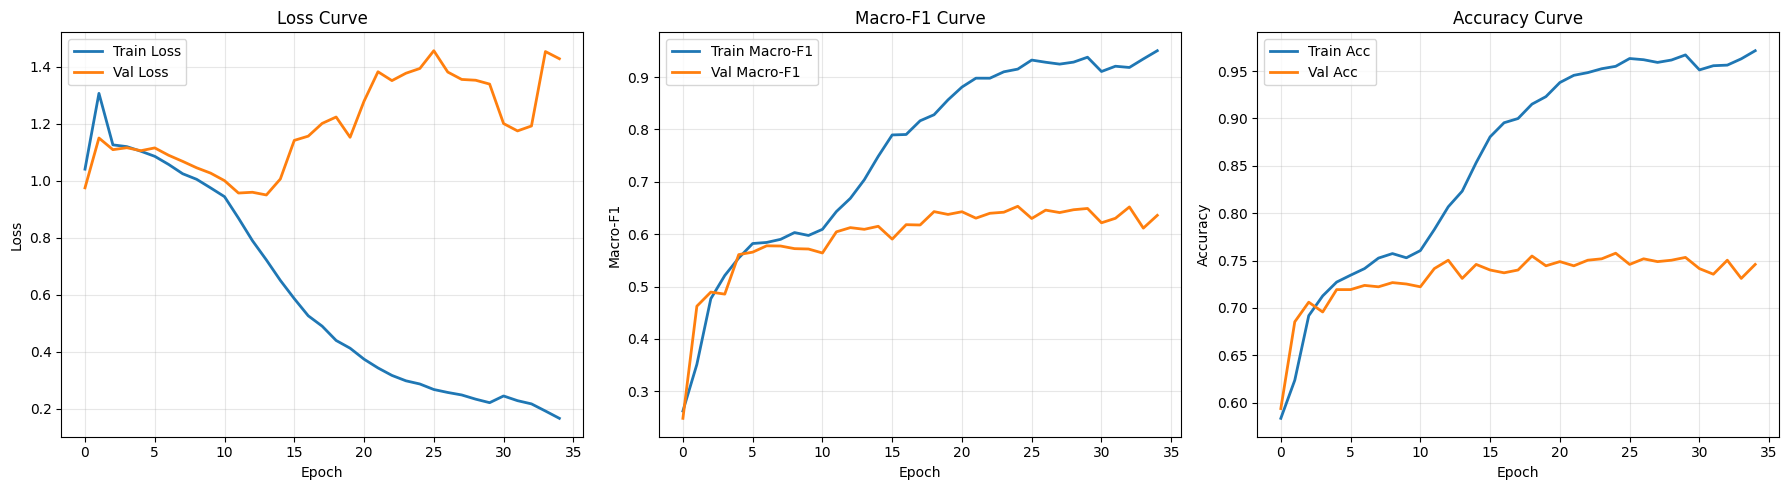

In [ ]:
# ============================================================
# CELL 9: TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Macro-F1
axes[1].plot(history["train_f1"], label="Train Macro-F1", linewidth=2)
axes[1].plot(history["val_f1"], label="Val Macro-F1", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("Macro-F1 Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accuracy
axes[2].plot(history["train_acc"], label="Train Acc", linewidth=2)
axes[2].plot(history["val_acc"], label="Val Acc", linewidth=2)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Accuracy Curve")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


TEST SET RESULTS
Accuracy:    0.7312
Macro-F1:    0.6119
Weighted-F1: 0.7155

              precision    recall  f1-score   support

    negative     0.6927    0.6078    0.6475       204
     neutral     0.6333    0.2714    0.3800        70
    positive     0.7521    0.8734    0.8083       403

    accuracy                         0.7312       677
   macro avg     0.6927    0.5842    0.6119       677
weighted avg     0.7220    0.7312    0.7155       677



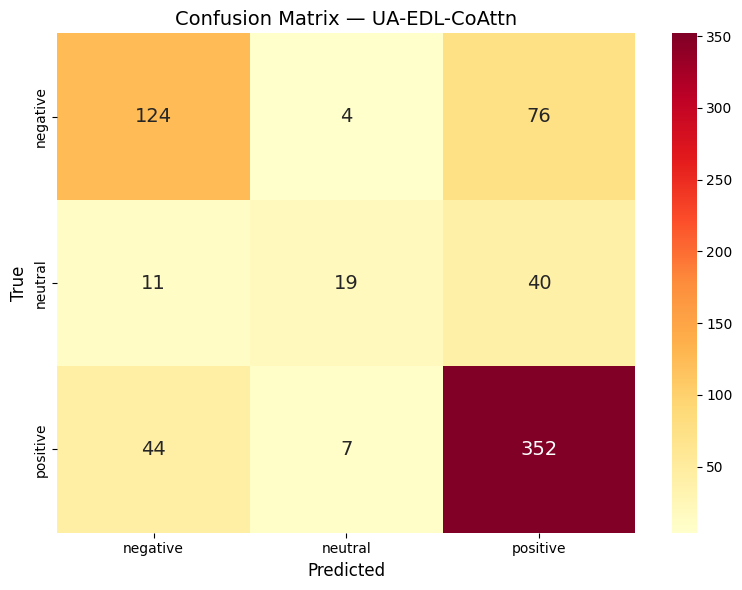

In [10]:
# ============================================================
# CELL 10: TEST SET EVALUATION
# ============================================================

test_metrics = evaluate(
    model, test_loader, class_weights,
    epoch=HP.MAX_EPOCHS, max_epoch=HP.MAX_EPOCHS,
    return_details=True
)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:    {test_metrics['accuracy']:.4f}")
print(f"Macro-F1:    {test_metrics['macro_f1']:.4f}")
print(f"Weighted-F1: {test_metrics['weighted_f1']:.4f}")
print()

# Classification Report
print(classification_report(
    test_metrics["labels"], test_metrics["preds"],
    target_names=["negative", "neutral", "positive"],
    digits=4
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(test_metrics["labels"], test_metrics["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"],
            ax=ax, annot_kws={"size": 14})
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title("Confusion Matrix — UA-EDL-CoAttn", fontsize=14)
plt.tight_layout()
plt.show()


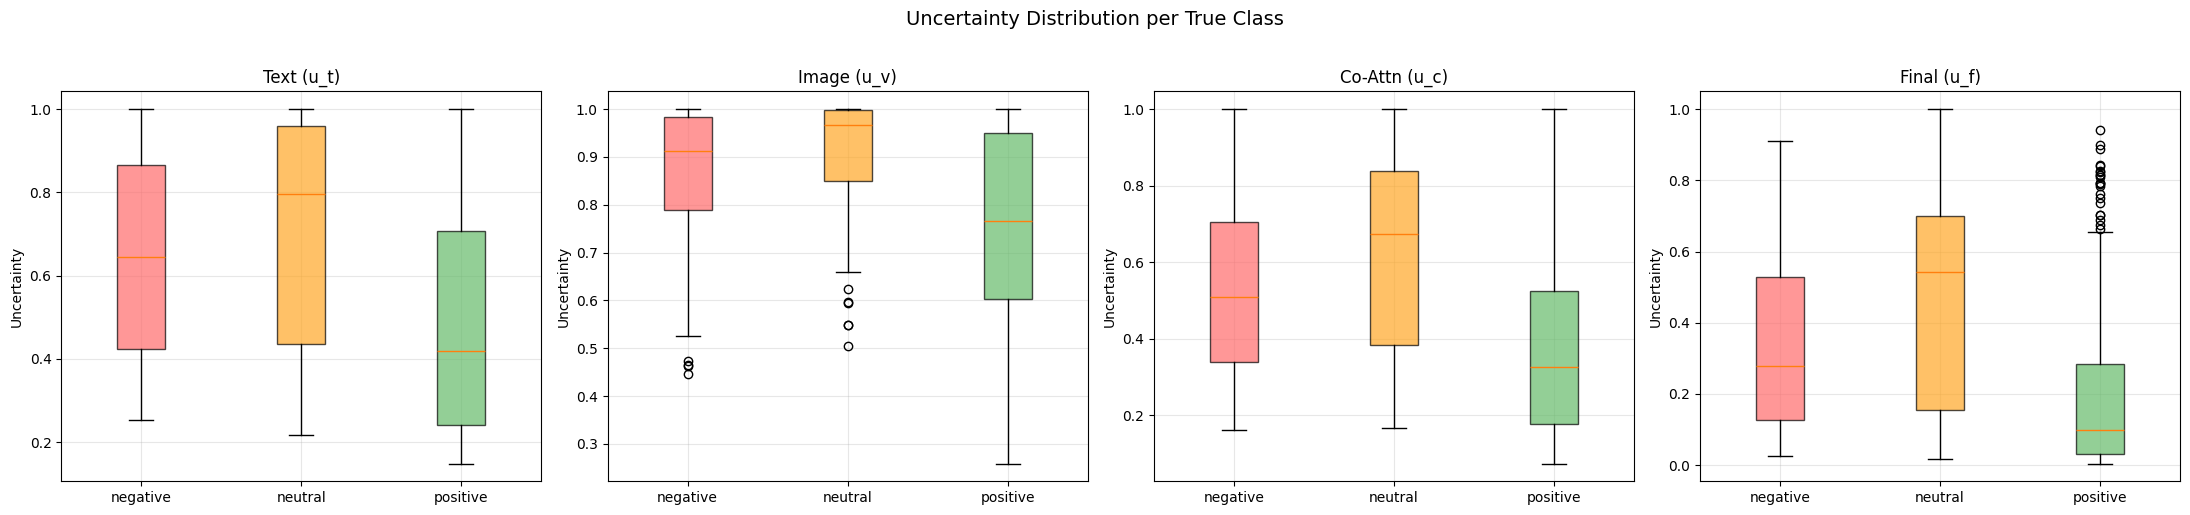

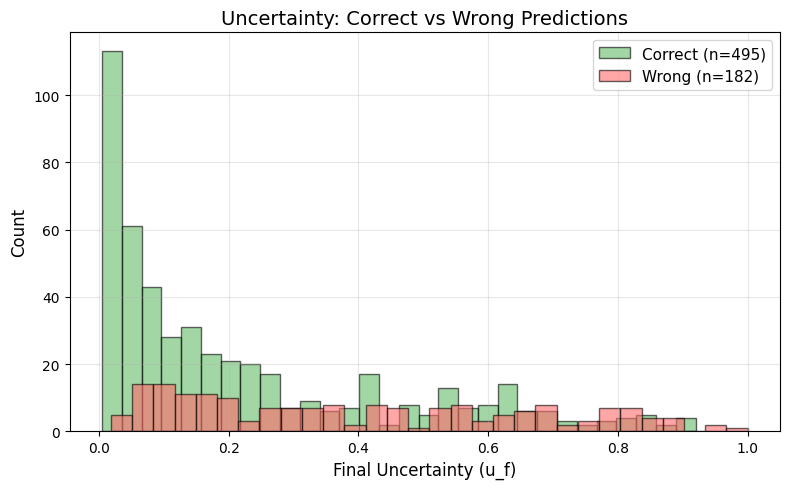

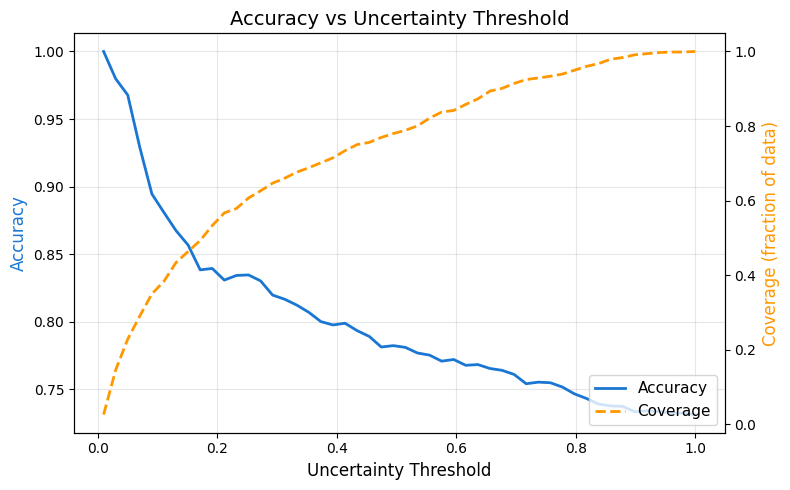

UNCERTAINTY STATISTICS

Text (u_t):
    negative: mean=0.6402, median=0.6435, std=0.2398
     neutral: mean=0.7166, median=0.7954, std=0.2622
    positive: mean=0.4847, median=0.4187, std=0.2690

Image (u_v):
    negative: mean=0.8655, median=0.9122, std=0.1376
     neutral: mean=0.8987, median=0.9670, std=0.1354
    positive: mean=0.7534, median=0.7651, std=0.1963

Co-Attn (u_c):
    negative: mean=0.5247, median=0.5097, std=0.2157
     neutral: mean=0.6150, median=0.6731, std=0.2428
    positive: mean=0.3792, median=0.3268, std=0.2378

Final (u_f):
    negative: mean=0.3398, median=0.2774, std=0.2400
     neutral: mean=0.4638, median=0.5411, std=0.3001
    positive: mean=0.1992, median=0.1001, std=0.2238

Correct predictions — mean u_f: 0.2206
Wrong predictions   — mean u_f: 0.4003


In [11]:
# ============================================================
# CELL 11: UNCERTAINTY ANALYSIS
# ============================================================

@torch.no_grad()
def collect_uncertainty_details(model, loader):
    """Collect per-head uncertainties for analysis."""
    model.eval()
    results = {"u_t": [], "u_v": [], "u_c": [], "u_f": [],
               "preds": [], "labels": [], "correct": []}

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask, images)

        alpha_f = outputs["alpha_f"]
        S_f = alpha_f.sum(dim=1, keepdim=True)
        preds = (alpha_f / S_f).argmax(dim=1)
        u_f = HP.NUM_CLASSES / S_f.squeeze(1)

        results["u_t"].extend(outputs["u_t"].squeeze(1).cpu().numpy())
        results["u_v"].extend(outputs["u_v"].squeeze(1).cpu().numpy())
        results["u_c"].extend(outputs["u_c"].squeeze(1).cpu().numpy())
        results["u_f"].extend(u_f.cpu().numpy())
        results["preds"].extend(preds.cpu().numpy())
        results["labels"].extend(labels.cpu().numpy())
        results["correct"].extend((preds == labels).cpu().numpy())

    return {k: np.array(v) for k, v in results.items()}

unc_data = collect_uncertainty_details(model, test_loader)

# --- Plot 1: Uncertainty Distribution per True Class ---
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
head_names = ["Text (u_t)", "Image (u_v)", "Co-Attn (u_c)", "Final (u_f)"]
head_keys = ["u_t", "u_v", "u_c", "u_f"]
class_names = ["negative", "neutral", "positive"]

for ax, key, name in zip(axes, head_keys, head_names):
    data_by_class = [unc_data[key][unc_data["labels"] == c] for c in range(3)]
    bp = ax.boxplot(data_by_class, labels=class_names, patch_artist=True)
    colors = ["#FF6B6B", "#FFA726", "#66BB6A"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(name, fontsize=12)
    ax.set_ylabel("Uncertainty")
    ax.grid(True, alpha=0.3)

plt.suptitle("Uncertainty Distribution per True Class", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Plot 2: Uncertainty vs Correctness ---
fig, ax = plt.subplots(figsize=(8, 5))
correct_u = unc_data["u_f"][unc_data["correct"] == 1]
wrong_u = unc_data["u_f"][unc_data["correct"] == 0]

ax.hist(correct_u, bins=30, alpha=0.6, label=f"Correct (n={len(correct_u)})",
        color="#66BB6A", edgecolor="black")
ax.hist(wrong_u, bins=30, alpha=0.6, label=f"Wrong (n={len(wrong_u)})",
        color="#FF6B6B", edgecolor="black")
ax.set_xlabel("Final Uncertainty (u_f)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Uncertainty: Correct vs Wrong Predictions", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 3: Accuracy vs Uncertainty Threshold ---
thresholds = np.linspace(0.01, 1.0, 50)
accs_at_threshold = []
coverage = []
for t in thresholds:
    mask = unc_data["u_f"] <= t
    if mask.sum() > 0:
        accs_at_threshold.append(accuracy_score(
            unc_data["labels"][mask], unc_data["preds"][mask]
        ))
        coverage.append(mask.mean())
    else:
        accs_at_threshold.append(0)
        coverage.append(0)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.plot(thresholds, accs_at_threshold, color="#1976D2", linewidth=2, label="Accuracy")
ax2.plot(thresholds, coverage, color="#FF9800", linewidth=2, linestyle="--", label="Coverage")
ax1.set_xlabel("Uncertainty Threshold", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12, color="#1976D2")
ax2.set_ylabel("Coverage (fraction of data)", fontsize=12, color="#FF9800")
ax1.set_title("Accuracy vs Uncertainty Threshold", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Stats ---
print("=" * 60)
print("UNCERTAINTY STATISTICS")
print("=" * 60)
for key, name in zip(head_keys, head_names):
    print(f"\n{name}:")
    for c, cn in enumerate(class_names):
        vals = unc_data[key][unc_data["labels"] == c]
        print(f"  {cn:>10}: mean={vals.mean():.4f}, median={np.median(vals):.4f}, std={vals.std():.4f}")
print(f"\nCorrect predictions — mean u_f: {correct_u.mean():.4f}")
print(f"Wrong predictions   — mean u_f: {wrong_u.mean():.4f}")


In [12]:
# ============================================================
# CELL 12: SAVE MODEL
# ============================================================

save_path = os.path.join(os.path.dirname(CFG.ROOT_DIR), "ua_edl_coattn_best.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "hyperparameters": {
        "proj_dim": HP.PROJ_DIM,
        "num_classes": HP.NUM_CLASSES,
        "dropout": HP.DROPOUT,
    },
    "class_weights": class_weights.cpu(),
    "history": history,
    "best_val_macro_f1": early_stopping.best_score,
    "test_metrics": {
        "accuracy": test_metrics["accuracy"],
        "macro_f1": test_metrics["macro_f1"],
        "weighted_f1": test_metrics["weighted_f1"],
    },
}, save_path)

print(f"✅ Model saved to: {save_path}")
print(f"   Best Val Macro-F1: {early_stopping.best_score:.4f}")
print(f"   Test Macro-F1:     {test_metrics['macro_f1']:.4f}")


✅ Model saved to: D:/ua_edl_coattn_best.pt
   Best Val Macro-F1: 0.6533
   Test Macro-F1:     0.6119
